# Problem 2 - Policy and Value Iteration
---

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Saving RL gridworld figures for the LaTeX writeup (set RL_FIG_PREFIX before learn_strategy)
FIGURES_DIR = "figures"
RL_FIG_PREFIX = None

## Util methods to represent the grid (do not modify)
#### You do not need modify any of these methods to complete Problem 2

In [2]:
# Maze state is represented as a 2-element NumPy array: (Y, X). Increasing Y is South.
grid = [
    'o.x.u',
    '..y..',
    '..y.*',
    '..z..']
topology = np.array([list(row) for row in grid])
flat_topology = topology.ravel()
rewards = {'.': 0, '*': 50, 'o': 4, 'u': 20, 'x': -10, 'y': -50,'z': -20}

row_count = len(grid) # 4
col_count = len(grid[0]) # 5
shape = (row_count, col_count) # (4, 5)

# Possible actions, expressed as (delta-y, delta-x)
directions="NSEW"
maze_actions = {
    'N': np.array([-1, 0]),
    'S': np.array([1, 0]),
    'E': np.array([0, 1]),
    'W': np.array([0, -1]),
}
actions = [maze_actions[direction] for direction in directions]


# Returns true if pos (y,x) is out of bounds
def is_wall(pos):
    (y, x) = pos
    return (y < 0 or y >= row_count or x < 0 or x >= col_count)

# Input is a flattened state, returns the reward at that state
def get_reward(state):
    assert (state in range(num_states)), f"get_reward: State was not an integer representing an in-bounds state ({state} was given)"
    return rewards.get(flat_topology[int(state)])

# Input is a flattened state, returns the unflattened representation of the state
def unflatten_index(flattened_index):
    return np.unravel_index(flattened_index, shape)

# Input state is an unflattened position and action is an index into the actions[] array
# Returns a tuple containing the new position of taking the action from the state
def move(state, action):
    return tuple((state + actions[action]).reshape(1, -1)[0])

# Returns an array of the "side states" when taking action beginning at unflattened position state
# Does not return states which are out of bounds
def get_side_states(action, state):
    side_states = []
    
    if action == 0 or action == 1:
        if not is_wall(move(state, 3)):
            side_states.append(move(state, 3))
        if not is_wall(move(state, 2)):
            side_states.append(move(state, 2))
    elif action == 2 or action == 3:
        if not is_wall(move(state, 0)):
            side_states.append(move(state, 0))
        if not is_wall(move(state, 1)):
            side_states.append(move(state, 1))
            
    return side_states
    
# Inputs s1, s2 are flattened states, action represents an index into the actions array
# Returns p(s2 | s1, action)
def get_transition_prob(s1, action, s2):
    # Check the inputs are valid
    assert (action in [0,1,2,3]), f"get_transition_prob: Action needs to be an integer in [0,1,2,3], but {action} was given"
    assert (s1 in range(num_states)), f"get_transition_prob: Input s1 was not an integer representing an in-bounds state ({s1} was given)"
    assert (s2 in range(num_states)), f"get_transition_prob: Input s2 was not an integer representing an in-bounds state ({s2} was given)"
    
    state1 = unflatten_index(int(s1))
    state2 = unflatten_index(int(s2))
    action = int(action)

    new_state = move(state1, action)

    sstates = get_side_states(action, state1)
    succeed_prb = 0.8
    slip_prb = 0.1

    # One of the side states was a wall: adjust probabilities accordingly.
    if len(sstates) == 1:
        succeed_prb = 0.9

    if is_wall(new_state):
        if(state1 == state2):
            return succeed_prb
    else:
        if(state2 == new_state):
            return succeed_prb

    # Oherwise, check if state2 is on either side
    for side_state in sstates:
        if(state2 == side_state):
            return slip_prb

    return 0.

In [3]:
# MAKE PLOTS (do not modify)

# Util to draw the value function V as numbers on a plot.
def make_value_plot(V):
    # Useful stats for the plot
    value_function = np.reshape(V, shape)

    # Write the value on top of each square
    indx, indy = np.arange(row_count), np.arange(col_count)

    fig, ax = plt.subplots()
    ax.imshow(value_function, interpolation='none', cmap= plt.get_cmap('coolwarm_r'))

    for s in range(len(V)):
        val = V[s]
        (xval, yval) = unflatten_index(s)
        t = "%.2f"%(val,) # format value with 1 decimal point
        ax.text(yval, xval, t, color='black', va='center', ha='center', size=15)
        

# Util to draw the policy pi as arrows on a plot.
def make_policy_plot(pi, iter_type, iter_num):
    # Useful stats for the plot
    row_count = len(grid)
    col_count = len(grid[0])
    policy_function = np.reshape(pi, shape)

    for row in range(row_count):
        for col in range(col_count):
            if policy_function[row,col] == 0:
                dx = 0; dy = -.5
            if policy_function[row,col] == 1:
                dx = 0; dy = .5
            if policy_function[row,col] == 2:
                dx = .5; dy = 0
            if policy_function[row,col] == 3:
                dx = -.5; dy = 0
            plt.arrow( col , row , dx , dy , shape='full', fc='w' , ec='gray' , lw=1., length_includes_head=True, head_width=.1 )
    plt.title(iter_type + ' Iteration, i = ' + str(iter_num))
    if RL_FIG_PREFIX is not None:
        os.makedirs(FIGURES_DIR, exist_ok=True)
        fname = f"{RL_FIG_PREFIX}_{iter_type.replace(' ', '')}_i{iter_num}.png"
        plt.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    plt.close("all")

In [4]:
np.random.seed(181)
VALUE_ITER = 'Value'
POLICY_ITER = 'Policy'

num_states = shape[0] * shape[1] # num_states = 20
num_actions = len(actions) # num_actions = 4

# Problem Description
Below you will implement policy and value iteration.

A state is represented as an integer from ``0`` to ``num_states - 1``
<br>
An action is represented as an integer in ``[0,1,2,3]``, which represents the four cardinal directions [N,S,E,W]

Each state has a reward associated with it. The agent gains the reward of a state when it takes an action at that state, not immediately upon entry.

``pi`` contains the learned policy at each state, represented by an array of length ``num_states``. In this exercise we will be implementing a deterministic policy, so each state has exactly one action associated with it.
<br>
ex: [2, 3, 1, 1, 2, 0, 1, 2, 2, 1, 3, 0, 0, 2, 2, 1, 3, 3, 2, 0]

``V`` represents the learned value function at each state. Like the above, it is also represented as an array of length ``num_states`` where the entry at index ``i`` represents the value of state ``i``.


## Helper methods

Recall that when you take an action in Gridworld, you won't always necessarily move in that direction. Instead there is some probability of moving to a state on either side. You do not need to calculate these transition probabilities yourself. Please use the helper functions ``get_transition_prob`` and ``get_reward`` in this file. The method headers are listed below:

``get_reward(state):`` Input is a state, output is the reward at that state

``get_transition_prob(s1, a, s2):`` Returns the probability of transitioning from state ``s1`` to state ``s2`` upon taking action ``a``.

An example is given below:

In [5]:
# Example usage
print(get_reward(14))
print(get_transition_prob(16, 0, 11))

50
0.8


## 1a) Policy Evaluation

Returns array ``V`` representing the value of policy ``pi`` using discount factor ``gamma``

Note: You can do this either closed-form or iteratively. If performed iteratively, please use a convergence tolerance of at least ``0.0001``

In [6]:
# Solution (iterative)
def policy_evaluation(pi, gamma):
    theta = 0.0001
    V = np.zeros(num_states)
    while True:
        delta = 0
        for s in range(num_states):
            v = V[s]
            a = int(pi[s])
            V[s] = sum(
                get_transition_prob(s, a, s2) * (get_reward(s) + gamma * V[s2])
                for s2 in range(num_states)
            )
            delta = max(delta, abs(v - V[s]))
        if delta <= theta:
            break
    return V

## 1b) Policy Iteration

Now that we have ``V`` computed in 1a), perform **one step** of policy iteration to return the updated policy ``pi_new``

In [7]:
def update_policy_iteration(V, gamma):
    pi_new = np.zeros(num_states)
    for s in range(num_states):
        action_values = np.zeros(num_actions)
        for a in range(num_actions):
            action_values[a] = sum(
                get_transition_prob(s, a, s2) * (get_reward(s) + gamma * V[s2])
                for s2 in range(num_states)
            )
        pi_new[s] = np.argmax(action_values)
    return pi_new

## 2) Value Iteration
Given a value function ``V``, perform **one step** of value iteration and return the updated ``V_new`` and corresponding ``pi_new``

In [8]:
def update_value_iteration(V, gamma):
    V_new = np.zeros(num_states)
    pi_new = np.zeros(num_states)
    for s in range(num_states):
        action_values = np.zeros(num_actions)
        for a in range(num_actions):
            action_values[a] = sum(
                get_transition_prob(s, a, s2) * (get_reward(s) + gamma * V[s2])
                for s2 in range(num_states)
            )
        V_new[s] = np.max(action_values)
        pi_new[s] = np.argmax(action_values)
    return V_new, pi_new

# Run code, plot results

The ``learn_strategy`` method iteratively runs the one-step methods you wrote in parts 1 and 2, either until the value function converges under <TT>ct</TT> or until a specified number of iterations <TT>max_iter</TT> have elapsed. It will also print out intermediate plots of the learned policy and value function at intervals of <TT>print_every</TT>. The arguments of the function are listed in more detail below:

``planning_type`` (<TT>string</TT>): 
    Specifies whether value or policy iteration is used to learn the strategy.
    
``max_iter`` (<TT>int</TT>):
    The maximum number of iterations (i.e. number of updates) the learning
    policy will be run for.
    
``print_every`` (<TT>int</TT>):
    The frequency at which the function will print value and policy plots.
    
``ct`` (<TT>float</TT>):
    The convergence tolerance used for policy or value iteration.
    
``gamma`` (<TT>float</TT>):
    The discount factor.

In [9]:
# Do not modify the learn_strategy method, but read through its code
def learn_strategy(planning_type = VALUE_ITER, max_iter = 10, print_every = 5, ct = None, gamma = 0.7):
    # Loop over some number of episodes
    V = np.zeros(num_states)
    pi = np.zeros(num_states)

    # Update Q-table using value/policy iteration until max iterations or until ct reached
    for n_iter in range(max_iter):
        V_prev = V.copy()

        # Update V and pi using value or policy iteration.
        if planning_type == VALUE_ITER:
            V, pi = update_value_iteration(V, gamma)
        elif planning_type == POLICY_ITER:
            V = policy_evaluation(pi, gamma)
            pi = update_policy_iteration(V, gamma)
        
        # Calculate the difference between this V and the previous V
        diff = np.absolute(np.subtract(V, V_prev))

        # Check that every state's difference is less than the convergence tol
        if ct and np.max(diff) < ct:
            make_value_plot(V = V)
            make_policy_plot(pi = pi, iter_type = planning_type, iter_num = n_iter+1)
            print("Converged at iteration " + str(n_iter+1))
            return 0

        # Make value plot and plot the policy
        if (n_iter % print_every == 0):
            make_value_plot(V = V)
            make_policy_plot(pi = pi, iter_type = planning_type, iter_num = n_iter+1)

## Show Policy Iteration

Beginning policy iteration (first 4 iterations).


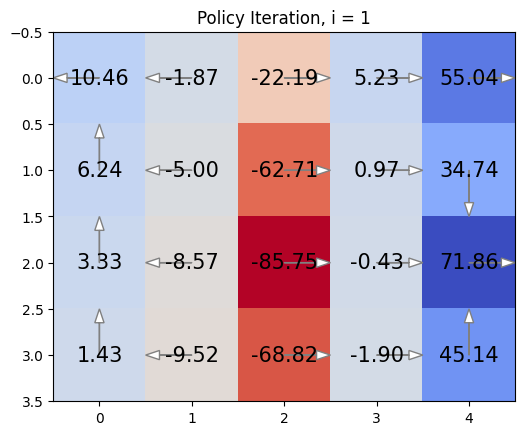

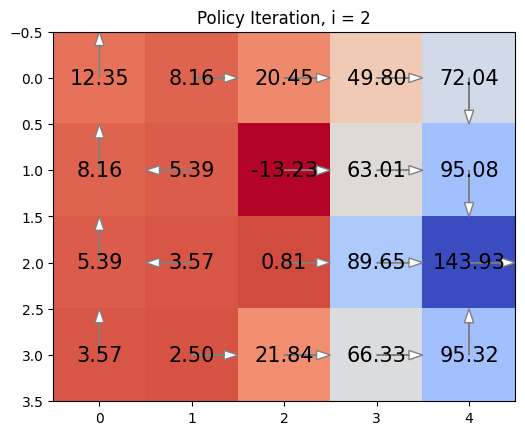

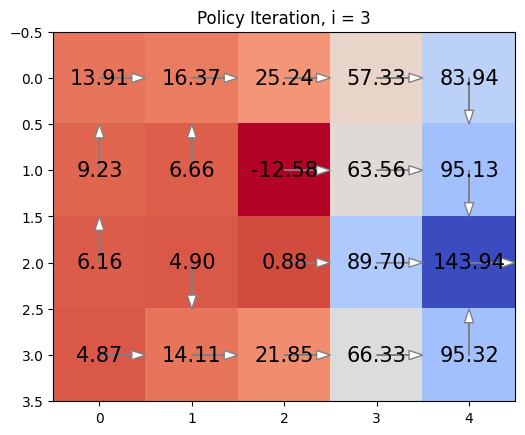

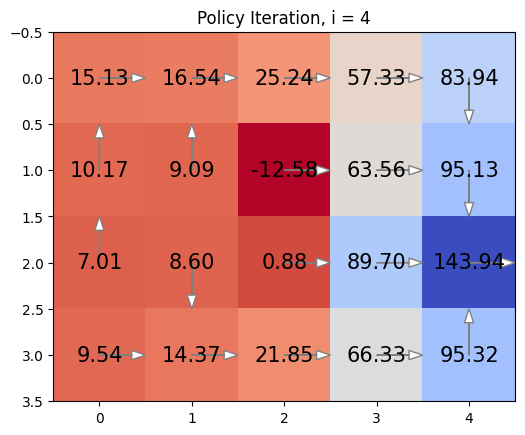

Policy iteration complete.



In [10]:
print('Beginning policy iteration (first 4 iterations).')
RL_FIG_PREFIX = "p2_pi_first4"
learn_strategy(planning_type=POLICY_ITER, max_iter=4, print_every=1, ct=0.01, gamma=0.7)
RL_FIG_PREFIX = None
print('Policy iteration complete.\n')

Policy iteration convergence experiments:

ct = 0.01:


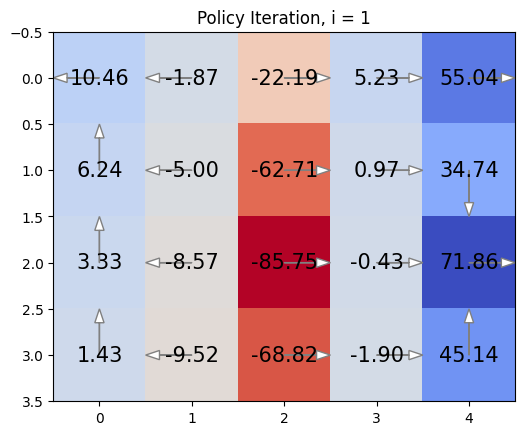

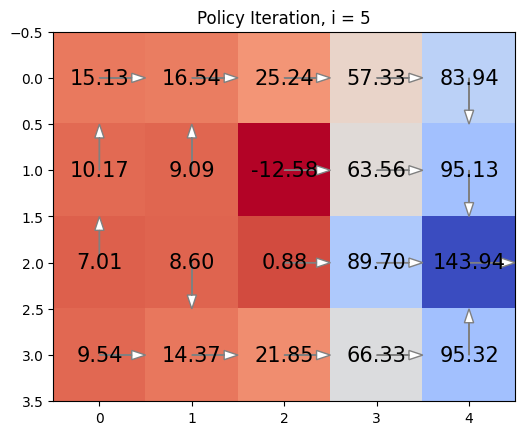

Converged at iteration 5

ct = 0.001:


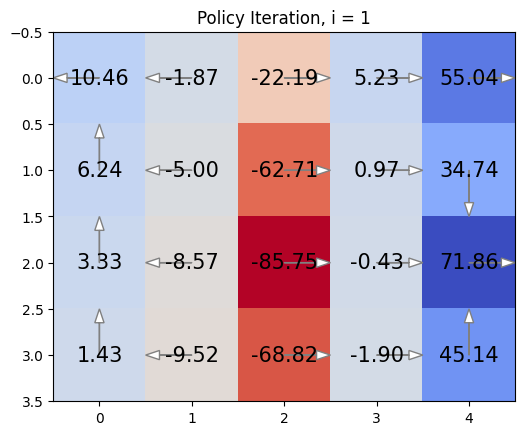

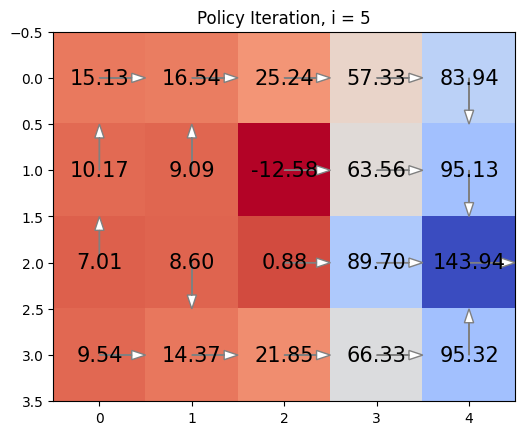

Converged at iteration 5

ct = 0.0001:


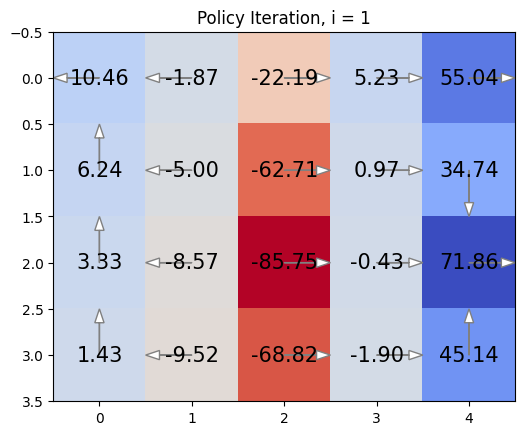

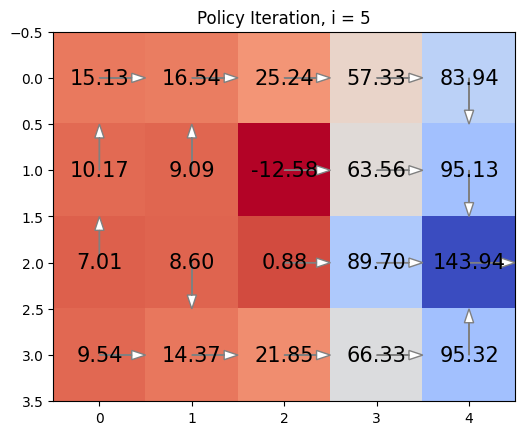

Converged at iteration 5


In [11]:
print('Policy iteration convergence experiments:')
for ct_val in [0.01, 0.001, 0.0001]:
    print(f'\nct = {ct_val}:')
    ct_tag = "ct" + str(ct_val).replace(".", "")
    RL_FIG_PREFIX = f"p2_pi_conv_{ct_tag}"
    learn_strategy(planning_type=POLICY_ITER, max_iter=100, print_every=100, ct=ct_val, gamma=0.7)
RL_FIG_PREFIX = None

## Show Value Iteration

Beginning value iteration (first 4 iterations).


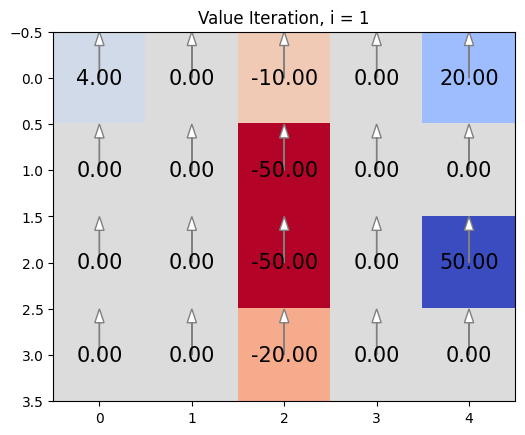

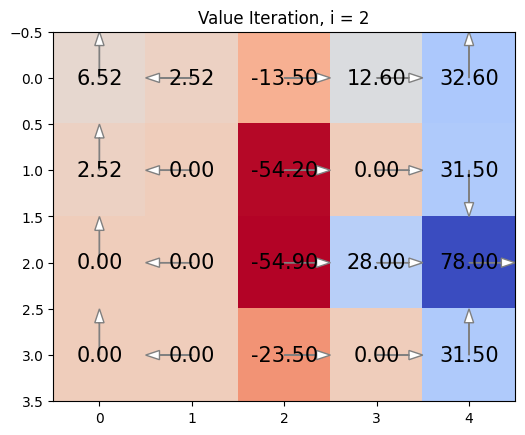

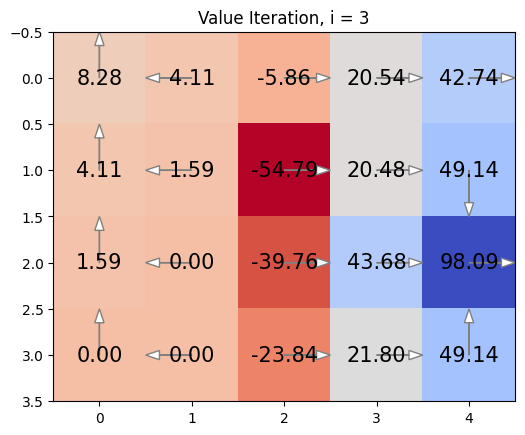

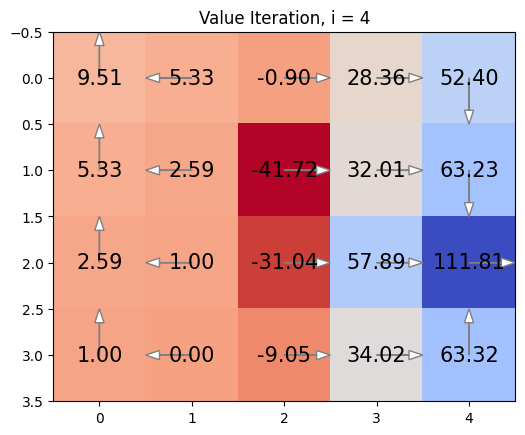

Value iteration complete.



In [12]:
print('Beginning value iteration (first 4 iterations).')
RL_FIG_PREFIX = "p2_vi_first4"
learn_strategy(planning_type=VALUE_ITER, max_iter=4, print_every=1, ct=0.01, gamma=0.7)
RL_FIG_PREFIX = None
print('Value iteration complete.\n')

Value iteration convergence experiments:

ct = 0.01:


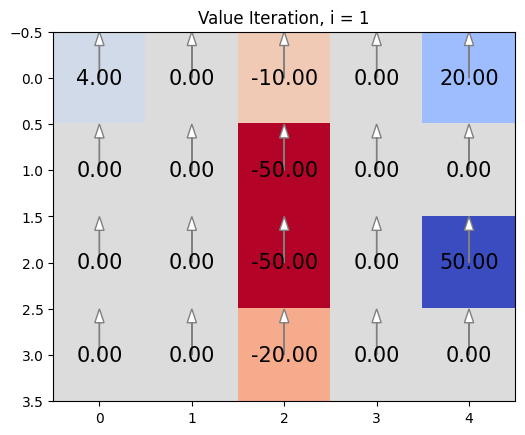

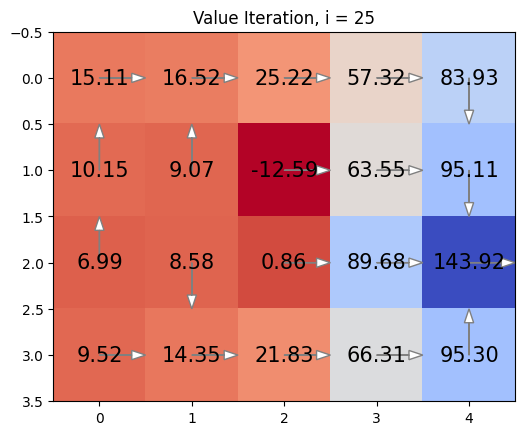

Converged at iteration 25

ct = 0.001:


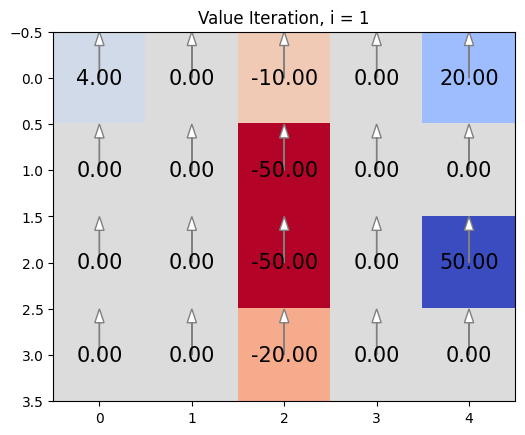

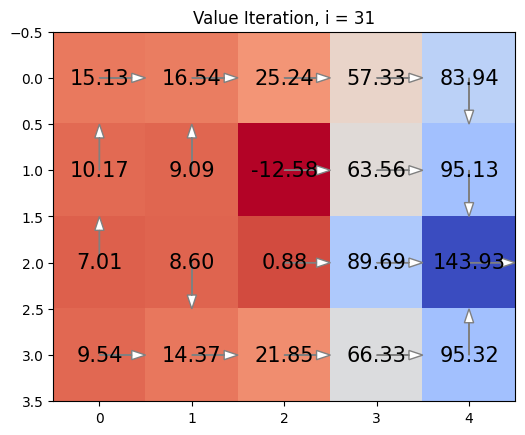

Converged at iteration 31

ct = 0.0001:


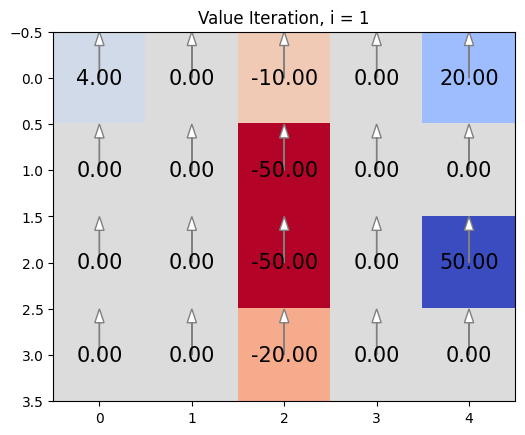

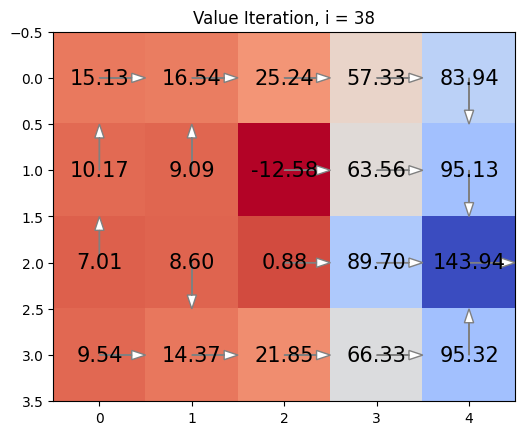

Converged at iteration 38


In [13]:
print('Value iteration convergence experiments:')
for ct_val in [0.01, 0.001, 0.0001]:
    print(f'\nct = {ct_val}:')
    ct_tag = "ct" + str(ct_val).replace(".", "")
    RL_FIG_PREFIX = f"p2_vi_conv_{ct_tag}"
    learn_strategy(planning_type=VALUE_ITER, max_iter=100, print_every=100, ct=ct_val, gamma=0.7)
RL_FIG_PREFIX = None

## Gamma sweep

Gamma sweep (converged policies):

gamma = 0.6:


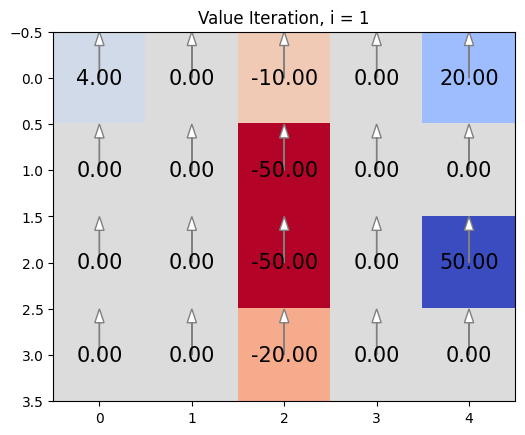

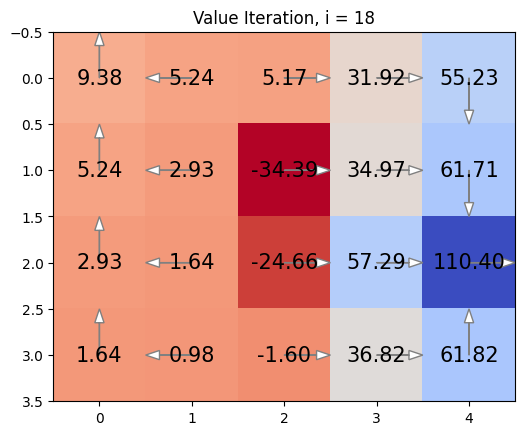

Converged at iteration 18

gamma = 0.7:


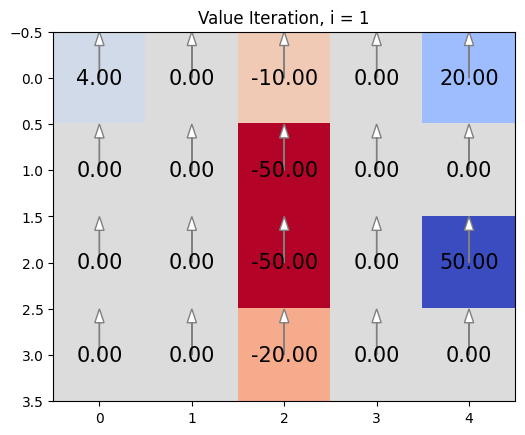

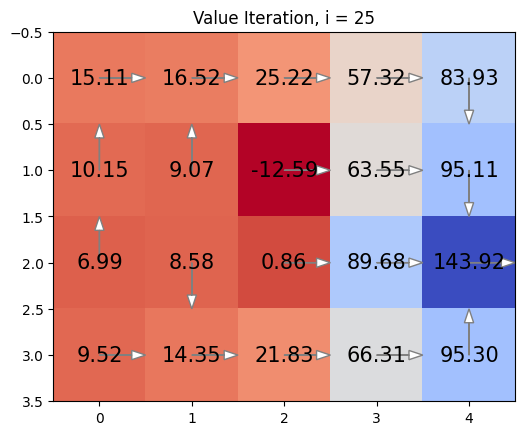

Converged at iteration 25

gamma = 0.8:


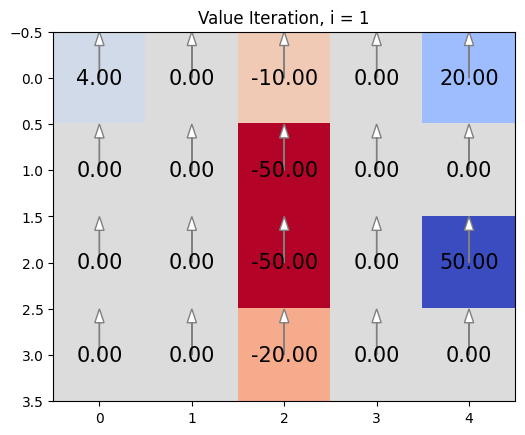

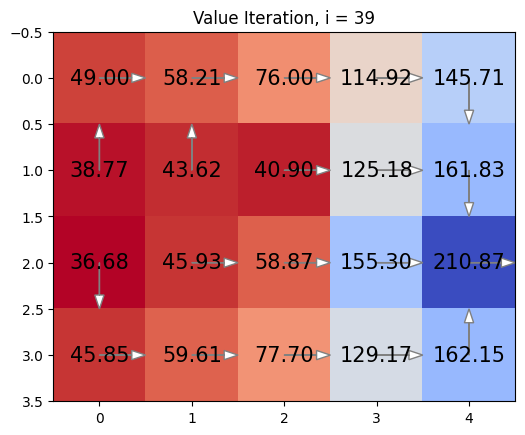

Converged at iteration 39

gamma = 0.9:


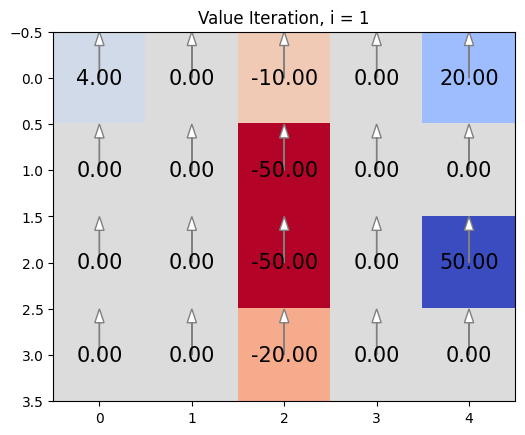

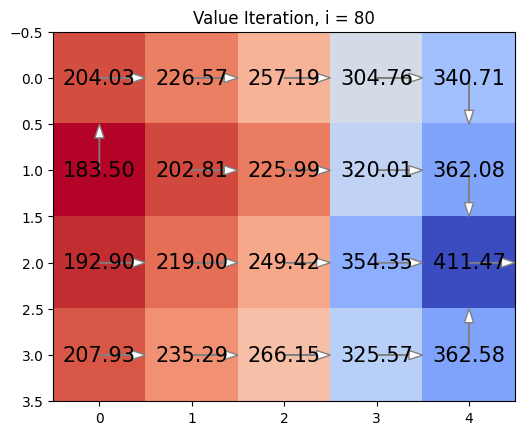

Converged at iteration 80


In [14]:
print('Gamma sweep (converged policies):')
for g in [0.6, 0.7, 0.8, 0.9]:
    print(f'\ngamma = {g}:')
    RL_FIG_PREFIX = "p2_gamma_" + str(g).replace(".", "")
    learn_strategy(planning_type=VALUE_ITER, max_iter=100, print_every=100, ct=0.01, gamma=g)
RL_FIG_PREFIX = None

# Problem 3 
---

Make sure to install pygame (i.e. through running `pip install pygame`)

In [15]:
import os
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import pygame as pg

# # uncomment this for animation
# from p3src.SwingyMonkey import SwingyMonkey

# uncomment this for no animation (use this for most purposes! it gets very slow otherwise)
from p3src.SwingyMonkeyNoAnimation import SwingyMonkey

pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [16]:
# Some constants. Don't edit this!
X_BINSIZE = 200
Y_BINSIZE = 100
X_SCREEN = 1400
Y_SCREEN = 900

In [17]:
class RandomJumper(object):
    """
    This agent jumps randomly.
    """

    def __init__(self):
        self.last_state = None
        self.last_action = None
        self.last_reward = None

        # We initialize our Q-value grid that has an entry for each action and state.
        # (action, rel_x, rel_y)
        self.Q = np.zeros((2, X_SCREEN // X_BINSIZE, Y_SCREEN // Y_BINSIZE))

    def reset(self):
        self.last_state = None
        self.last_action = None
        self.last_reward = None

    def discretize_state(self, state):
        """
        Discretize the position space to produce binned features.
        rel_x = the binned relative horizontal distance between the monkey and the tree
        rel_y = the binned relative vertical distance between the monkey and the tree
        """

        rel_x = int((state["tree"]["dist"]) // X_BINSIZE)
        rel_y = int((state["tree"]["top"] - state["monkey"]["top"]) // Y_BINSIZE)
        return (rel_x, rel_y)

    def action_callback(self, state):
        """
        Implement this function to learn things and take actions.
        Return 0 if you don't want to jump and 1 if you do.
        """

        new_action = npr.rand() < 0.1
        new_state = state

        self.last_action = new_action
        self.last_state = new_state

        return self.last_action

    def reward_callback(self, reward):
        """This gets called so you can see what reward you get."""

        self.last_reward = reward

In [18]:
class Learner(object):
    '''
    Q-learning agent with gravity inference, velocity binning,
    and exponentially decaying epsilon-greedy exploration.
    '''

    def __init__(self, alpha=0.5, gamma_rl=0.9, epsilon0=0.3, epsilon_decay=0.95):
        self.last_state = None
        self.last_action = None
        self.last_reward = None

        self.alpha = alpha
        self.gamma_rl = gamma_rl
        self.epsilon0 = epsilon0
        self.epsilon = epsilon0
        self.epsilon_decay = epsilon_decay
        self.epoch = 0

        self.n_dist = 4
        self.n_dy = 12
        self.n_vel = 7
        self.n_grav = 2
        self.dy_bin_sz = 30
        self.vel_bin_sz = 8

        self.gravity = None
        self.first_timestep = True
        self.first_state = None

        self.Q = np.zeros((2, self.n_dist, self.n_dy,
                           self.n_vel, self.n_grav))

    def reset(self):
        self.last_state = None
        self.last_action = None
        self.last_reward = None
        self.gravity = None
        self.first_timestep = True
        self.first_state = None
        self.epoch += 1
        self.epsilon = self.epsilon0 * (self.epsilon_decay ** self.epoch)

    def discretize_state(self, state):
        rel_x = int(state["tree"]["dist"] // 150)
        rel_x = np.clip(rel_x, 0, self.n_dist - 1)

        gap_center = (state["tree"]["top"] + state["tree"]["bot"]) / 2.0
        monkey_center = (state["monkey"]["top"] + state["monkey"]["bot"]) / 2.0
        dy = gap_center - monkey_center
        dy_bin = int(dy // self.dy_bin_sz) + self.n_dy // 2
        dy_bin = np.clip(dy_bin, 0, self.n_dy - 1)

        vel = state["monkey"]["vel"]
        vel_bin = int(vel // self.vel_bin_sz) + self.n_vel // 2
        vel_bin = np.clip(vel_bin, 0, self.n_vel - 1)

        grav_bin = 0 if self.gravity <= 2 else 1

        return (rel_x, dy_bin, vel_bin, grav_bin)

    def update_gravity(self, state):
        if self.first_timestep or (self.gravity is None and self.first_state is not None
                                    and self.first_state['monkey']['top'] == state['monkey']['top']):
            self.first_timestep = False
            self.first_state = state
            self.last_action = 0
            return False

        if self.gravity is None:
            self.gravity = int(self.first_state['monkey']['top'] - state['monkey']['top'])

        return True

    def action_callback(self, state):
        if not self.update_gravity(state):
            return self.last_action

        cur_state = self.discretize_state(state)

        if self.last_state is not None:
            Q_cur = max(self.Q[0][cur_state], self.Q[1][cur_state])
            self.Q[self.last_action][self.last_state] += self.alpha * (
                self.last_reward + self.gamma_rl * Q_cur
                - self.Q[self.last_action][self.last_state]
            )

        if npr.rand() < self.epsilon:
            action = npr.choice([0, 1])
        else:
            action = int(np.argmax([self.Q[0][cur_state], self.Q[1][cur_state]]))

        self.last_state = cur_state
        self.last_action = action

        return action

    def reward_callback(self, reward):
        self.last_reward = reward

In [19]:
### more advanced agent, don't need this for full credit
class GravityLearner(object):
    '''
    This agent uses Q-learning and infers gravity!
    '''

    def __init__(self):
        self.last_state  = None
        self.last_action = None
        self.last_reward = None

        # Q-learning parameters
        self.alpha = 0.1
        self.epsilon = 0.001
        self.gamma = 0.9

        # Gravity parameters
        self.gravity = None
        self.first_timestep = True

        # We initialize our Q-value grid that has an entry for each action and state.
        # (action, rel_x, rel_y)
        self.Q = np.zeros((2, X_SCREEN // X_BINSIZE, Y_SCREEN // Y_BINSIZE, 5))

    def reset(self):
        self.last_state  = None
        self.last_action = None
        self.last_reward = None

        # Gravity parameters
        self.gravity = None
        self.first_timestep = True

    def discretize_state(self, state, gravity):
        '''
        Discretize the position space to produce binned features.
        rel_x = the binned relative horizontal distance between the monkey and the tree
        rel_y = the binned relative vertical distance between the monkey and the tree        
        '''

        rel_x = int((state["tree"]["dist"]) // X_BINSIZE)
        rel_y = int((state["tree"]["top"] - state["monkey"]["top"]) // Y_BINSIZE)
        return (rel_x, rel_y, self.gravity) 

    def update_gravity(self, state):
        '''
        Use the first timestep to determine the epoch's 'gravity'.
        Returns True if gravity has been updated, False otherwise. 
        '''

        # Check that the monkey has moved.
        if self.first_timestep or (self.gravity == None and self.first_state['monkey']['top'] == state['monkey']['top']):
            self.first_timestep = False
            self.first_state = state
            self.last_action = 0
            return False
        
        # Set gravity as the distance the monkey falls in the first timestep.
        elif self.gravity is None:
            self.gravity = int(self.first_state['monkey']['top'] - state['monkey']['top'])
        
        return True

    def action_callback(self, state):
        '''
        Implement this function to learn things and take actions.
        Return 0 if you don't want to jump and 1 if you do.
        '''

        # Continue if gravity has been updated.
        if self.update_gravity(state):

            # Discretize 'state' to get your transformed 'current state' features.
            cur_state = self.discretize_state(state, self.gravity)

            # Perform the Q-Learning update using 'current state' and the 'last state'.
            Q_sa = (self.Q[0][cur_state], self.Q[1][cur_state])
            self.Q[self.last_action][self.last_state] = ((1-self.alpha) * self.Q[self.last_action][self.last_state] 
                                                           + self.alpha * (self.last_reward + self.gamma * np.max(Q_sa)))

            # Choose the next action using an epsilon-greedy policy.
            if npr.rand() < self.epsilon:
                self.last_action = npr.choice([0,1])
            else:
                self.last_action = np.argmax(Q_sa)

            self.last_state = cur_state

        return self.last_action

    
    def reward_callback(self, reward):
        '''This gets called so you can see what reward you get.'''

        self.last_reward = reward

In [20]:
def run_games(learner, hist, iters=100, t_len=100, quit_pygame_at_end=True):
    """
    Driver function to simulate learning by having the agent play a sequence of games.
    Set quit_pygame_at_end=False when running several sweeps in one session.
    """
    for ii in range(iters):
        # Make a new monkey object.
        swing = SwingyMonkey(sound=False,  # Don't play sounds.
                             text="Epoch %d" % (ii),  # Display the epoch on screen.
                             tick_length=t_len,  # Make game ticks super fast.
                             action_callback=learner.action_callback,
                             reward_callback=learner.reward_callback)

        # Loop until you hit something.
        while swing.game_loop():
            pass

        # Save score history.
        hist.append(swing.score)

        # Reset the state of the learner.
        learner.reset()
    if quit_pygame_at_end:
        pg.quit()
    return

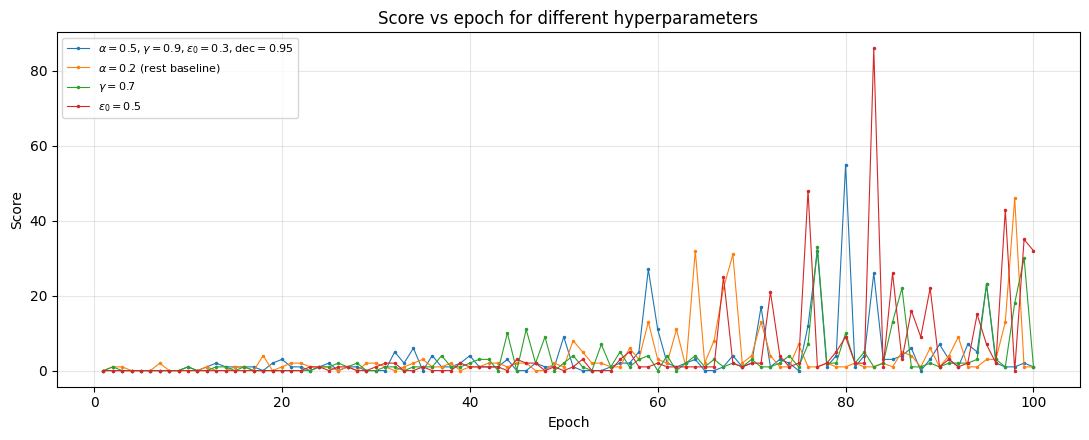

alpha  gamma_rl  eps0   decay  max_score  best_epoch
0.5    0.9       0.3    0.95   55.0       80
0.2    0.9       0.3    0.95   46.0       98
0.5    0.7       0.3    0.95   33.0       77
0.5    0.9       0.5    0.95   86.0       83


In [21]:
# Compare several hyperparameter settings (assignment asks for score vs epoch across parameters).
npr.seed(181)

PARAM_RUNS = [
    dict(alpha=0.5, gamma_rl=0.9, epsilon0=0.3, epsilon_decay=0.95, label=r'$\alpha{=}0.5,\gamma{=}0.9,\epsilon_0{=}0.3,\mathrm{dec}{=}0.95$'),
    dict(alpha=0.2, gamma_rl=0.9, epsilon0=0.3, epsilon_decay=0.95, label=r'$\alpha{=}0.2$ (rest baseline)'),
    dict(alpha=0.5, gamma_rl=0.7, epsilon0=0.3, epsilon_decay=0.95, label=r'$\gamma{=}0.7$'),
    dict(alpha=0.5, gamma_rl=0.9, epsilon0=0.5, epsilon_decay=0.95, label=r'$\epsilon_0{=}0.5$'),
]

rows = []
all_hists = []
plt.figure(figsize=(11, 4.5))

for i, cfg in enumerate(PARAM_RUNS):
    label = cfg.pop('label')
    kw = {k: cfg[k] for k in ('alpha', 'gamma_rl', 'epsilon0', 'epsilon_decay')}
    agent = Learner(**kw)
    hist = []
    last = i == len(PARAM_RUNS) - 1
    run_games(agent, hist, 100, 100, quit_pygame_at_end=last)
    arr = np.array(hist, dtype=float)
    all_hists.append(arr)
    mx = float(np.max(hist))
    ep = int(np.argmax(hist)) + 1
    rows.append({**kw, 'max_score': mx, 'best_epoch': ep, 'label': label})
    plt.plot(range(1, len(hist) + 1), hist, marker='.', linewidth=0.8, markersize=3, label=label)

plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Score vs epoch for different hyperparameters')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig(os.path.join('figures', 'p3_score_vs_epoch.png'), dpi=150)
plt.show()

# Primary hist for backward compatibility: first configuration (original defaults)
hist = list(all_hists[0])
np.save('hist', np.array(hist))
np.savez('p3_param_sweep.npz', **{'run{}'.format(i): all_hists[i] for i in range(len(all_hists))})

print('alpha  gamma_rl  eps0   decay  max_score  best_epoch')
for r in rows:
    print(f"{r['alpha']:<5}  {r['gamma_rl']:<8}  {r['epsilon0']:<5}  {r['epsilon_decay']:<5}  {r['max_score']:<9}  {r['best_epoch']}")